# 06 Weekly Prophet Forecasting

Final version: Vanilla Palestine, weekly, Prophet, additive only, clipped engagement_rate.


In [1]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


## 1) Project Paths


In [2]:
try:
    PROJECT_ROOT = Path(__file__).resolve().parents[2]
except NameError:
    CURRENT_DIR = Path.cwd().resolve()
    PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

sys.path.insert(0, str(NOTEBOOKS_DIR))

from utils.utils import ensure_project_dirs
from utils.evaluation import regression_metrics, rank_models

ensure_project_dirs()

KPI_PATH = PROJECT_ROOT / "data" / "processed" / "vanilla_kpi_dataset.json"

OUTPUTS_DIR = NOTEBOOKS_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)


## 2) Load Vanilla Dataset


In [3]:
df = pd.read_json(KPI_PATH)

required_columns = [
    "business_name",
    "sector",
    "post_date",
    "engagement_rate",
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df["business_name"] = df["business_name"].astype(str).str.strip()
df["sector"] = df["sector"].astype(str).str.strip()

df["post_date"] = pd.to_datetime(
    df["post_date"],
    unit="ms",
    errors="coerce"
)

df["engagement_rate"] = pd.to_numeric(
    df["engagement_rate"],
    errors="coerce"
)

df = df.dropna(
    subset=[
        "business_name",
        "sector",
        "post_date",
        "engagement_rate",
    ]
)

BUSINESS_NAME = df["business_name"].iloc[0]

print("Business:", BUSINESS_NAME)
print("Date range:", df["post_date"].min(), "to", df["post_date"].max())
print("Number of posts:", len(df))


Business: Vanilla Palestine
Date range: 2023-08-11 00:00:00 to 2026-04-15 00:00:00
Number of posts: 95


## 3) Clip Extreme Spikes


In [4]:
upper_limit = df["engagement_rate"].quantile(0.99)

df["engagement_rate_clipped"] = np.clip(
    df["engagement_rate"],
    None,
    upper_limit
)


## 4) Build Weekly Time Series


In [5]:
def build_weekly_ts(frame):
    ts = (
        frame.set_index("post_date")["engagement_rate_clipped"]
        .resample("W-MON")
        .mean()
        .dropna()
        .reset_index()
        .rename(
            columns={
                "post_date": "ds",
                "engagement_rate_clipped": "y",
            }
        )
    )

    ts["ds"] = pd.to_datetime(ts["ds"])
    return ts


weekly_ts = build_weekly_ts(df)

print("Number of weekly points:", len(weekly_ts))

if len(weekly_ts) < 12:
    raise ValueError(
        f"Not enough weekly data for forecasting. "
        f"Available weekly points: {len(weekly_ts)}"
    )


Number of weekly points: 40


## 5) Prophet Forecast


In [6]:
from prophet import Prophet


def run_prophet_forecast(ts, periods=8):
    ts = ts.sort_values("ds").reset_index(drop=True)

    split = int(len(ts) * 0.8)

    train = ts.iloc[:split]
    test = ts.iloc[split:]

    if len(test) < 2:
        raise ValueError(
            f"Not enough test weeks. Test weeks: {len(test)}"
        )

    experiment_rows = []
    prediction_store = {}

    # Final recommended settings:
    # weekly data, additive mode only, no yearly seasonality.
    cp_vals = [0.01, 0.05, 0.1]

    for cp in cp_vals:
        model = Prophet(
            changepoint_prior_scale=cp,
            seasonality_mode="additive",
            yearly_seasonality=False,
            weekly_seasonality=True,
            daily_seasonality=False,
        )

        model.fit(train)

        future = model.make_future_dataframe(
            periods=len(test),
            freq="W-MON"
        )

        pred = model.predict(future)[["ds", "yhat"]].tail(len(test))

        metrics = regression_metrics(test["y"], pred["yhat"])

        experiment_rows.append(
            {
                "business_name": BUSINESS_NAME,
                "model": "prophet",
                "aggregation": "weekly",
                "changepoint_prior_scale": cp,
                "seasonality_mode": "additive",
                "yearly_seasonality": False,
                **metrics,
            }
        )

        prediction_store[cp] = (train, test, pred)

    exp_df = pd.DataFrame(experiment_rows)

    ranked = rank_models(
        exp_df,
        lower_is_better_cols=["MAE", "RMSE", "MAPE"]
    )

    best = ranked.iloc[0]
    best_cp = best["changepoint_prior_scale"]

    train, test, pred = prediction_store[best_cp]

    test_forecast = test.merge(pred, on="ds", how="left")
    test_forecast["forecast_type"] = "test"
    test_forecast["yhat_lower"] = np.nan
    test_forecast["yhat_upper"] = np.nan

    final_model = Prophet(
        changepoint_prior_scale=float(best_cp),
        seasonality_mode="additive",
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
    )

    # Train final model on ALL weekly data
    final_model.fit(ts)

    future = final_model.make_future_dataframe(
        periods=periods,
        freq="W-MON"
    )

    full_forecast = final_model.predict(future)[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ]

    future_forecast = full_forecast[
        full_forecast["ds"] > ts["ds"].max()
    ].copy()

    future_forecast["y"] = np.nan
    future_forecast["forecast_type"] = "future"

    forecast = pd.concat(
        [
            test_forecast[
                ["ds", "y", "yhat", "yhat_lower", "yhat_upper", "forecast_type"]
            ],
            future_forecast[
                ["ds", "y", "yhat", "yhat_lower", "yhat_upper", "forecast_type"]
            ],
        ],
        ignore_index=True,
    )

    forecast["business_name"] = BUSINESS_NAME
    forecast["model"] = "prophet"
    forecast["aggregation"] = "weekly"
    forecast["target"] = "engagement_rate_clipped"
    forecast["changepoint_prior_scale"] = best_cp
    forecast["seasonality_mode"] = "additive"
    forecast["yearly_seasonality"] = False

    return forecast, ranked


forecast, forecast_metrics = run_prophet_forecast(
    weekly_ts,
    periods=8
)


Importing plotly failed. Interactive plots will not work.
00:19:28 - cmdstanpy - INFO - Chain [1] start processing
00:19:28 - cmdstanpy - INFO - Chain [1] done processing
00:19:28 - cmdstanpy - INFO - Chain [1] start processing
00:19:29 - cmdstanpy - INFO - Chain [1] done processing
00:19:29 - cmdstanpy - INFO - Chain [1] start processing
00:19:30 - cmdstanpy - INFO - Chain [1] done processing
00:19:30 - cmdstanpy - INFO - Chain [1] start processing
00:19:30 - cmdstanpy - INFO - Chain [1] done processing


## 6) Save Outputs


In [ ]:
forecast.to_csv(
    OUTPUTS_DIR / "vanilla_weekly_prophet_forecast.csv",
    index=False
)

forecast_metrics.to_csv(
    OUTPUTS_DIR / "vanilla_weekly_prophet_forecast_metrics.csv",
    index=False
)


## 7) Plot Forecast


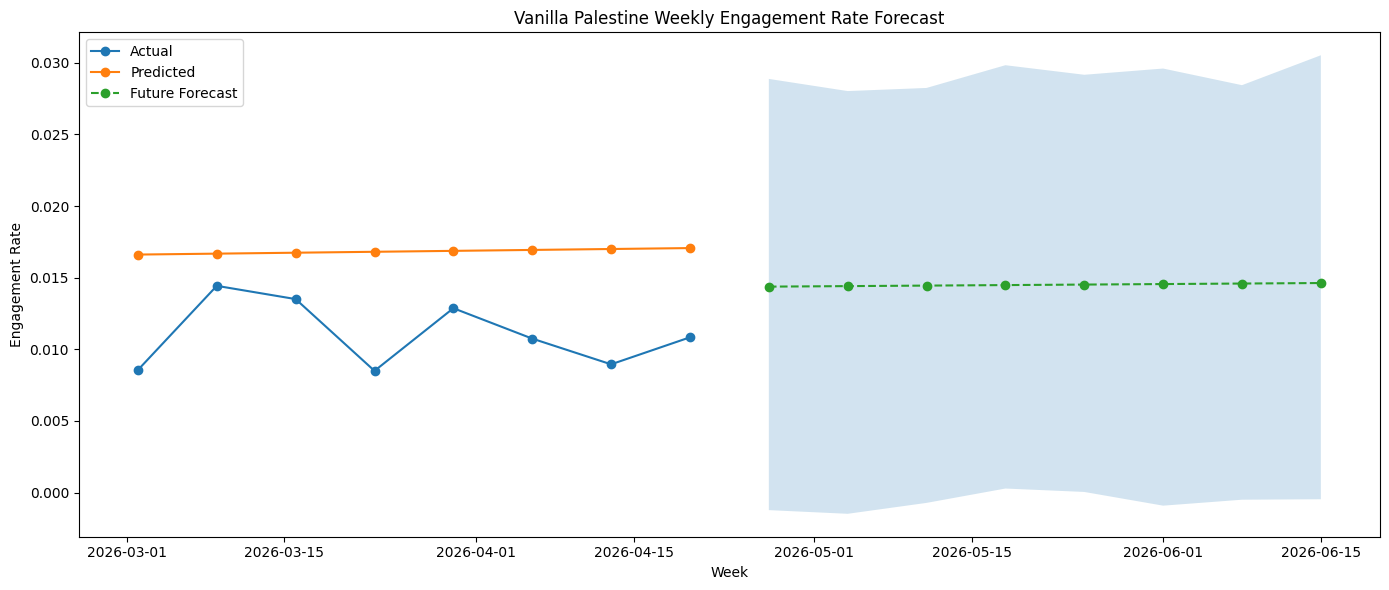

In [7]:
test_part = forecast[forecast["forecast_type"] == "test"]
future_part = forecast[forecast["forecast_type"] == "future"]

plt.figure(figsize=(14, 6))

plt.plot(
    test_part["ds"],
    test_part["y"],
    marker="o",
    label="Actual"
)

plt.plot(
    test_part["ds"],
    test_part["yhat"],
    marker="o",
    label="Predicted"
)

plt.plot(
    future_part["ds"],
    future_part["yhat"],
    marker="o",
    linestyle="--",
    label="Future Forecast"
)

plt.fill_between(
    future_part["ds"],
    future_part["yhat_lower"],
    future_part["yhat_upper"],
    alpha=0.2
)

plt.title(f"{BUSINESS_NAME} Weekly Engagement Rate Forecast")
plt.xlabel("Week")
plt.ylabel("Engagement Rate")
plt.legend()
plt.tight_layout()

plt.savefig(
    OUTPUTS_DIR / "vanilla_weekly_prophet_forecast.png"
)

plt.show()


## 8) Final Summary


In [8]:
print("Vanilla Weekly Prophet Forecasting completed successfully.")
print()
print("Business:")
print(BUSINESS_NAME)
print()
print("Input file:")
print(KPI_PATH)
print()
print("Saved outputs to:")
print(OUTPUTS_DIR)
print()
print("Generated files:")
print("- vanilla_weekly_prophet_forecast.csv")
print("- vanilla_weekly_prophet_forecast_metrics.csv")
print("- vanilla_weekly_prophet_forecast.png")
print()
print("Forecast target:")
print("- engagement_rate_clipped")
print()
print("Forecast horizon:")
print("- next 8 weeks")


Vanilla Weekly Prophet Forecasting completed successfully.

Business:
Vanilla Palestine

Input file:
C:\Users\hanai\marketing\data\processed\vanilla_kpi_dataset.json

Saved outputs to:
C:\Users\hanai\marketing\notebooks\outputs

Generated files:
- vanilla_weekly_prophet_forecast.csv
- vanilla_weekly_prophet_forecast_metrics.csv
- vanilla_weekly_prophet_forecast.png

Forecast target:
- engagement_rate_clipped

Forecast horizon:
- next 8 weeks
